In [ ]:
CREATE TABLE Students (
    student_id INT PRIMARY KEY,
    name VARCHAR(50) NOT NULL,
    email VARCHAR(100) UNIQUE,
    birth_date DATE,
    major VARCHAR(50) DEFAULT 'General'
);

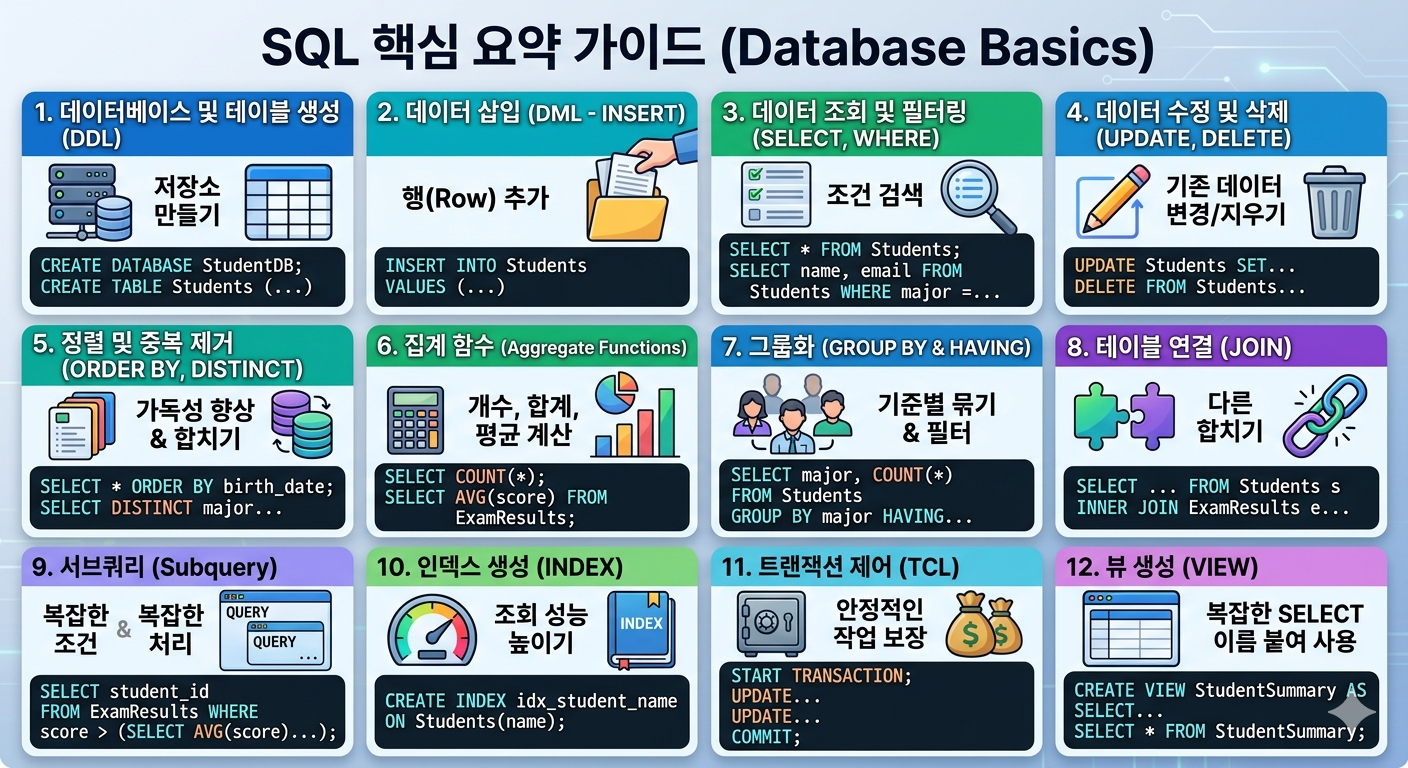

<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">데이터베이스 및 테이블 생성</span>

In [ ]:
-- 데이터베이스 생성
CREATE DATABASE StudentDB;
USE StudentDB;

-- 학생 정보를 담는 테이블 생성
CREATE TABLE Students (
    student_id INT PRIMARY KEY,      -- 기본키
    name VARCHAR(50) NOT NULL,       -- 필수 입력
    email VARCHAR(100) UNIQUE,       -- 중복 불가
    birth_date DATE,
    major VARCHAR(50) DEFAULT 'General' -- 기본값 설정
);

<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">데이터 삽입(DML-INSERT)</span>

In [ ]:
INSERT INTO Students (student_id, name, email, birth_date, major)
VALUES (1, '김철수', 'chul@example.com', '2001-03-12', 'Computer Science'),
       (2, '이영희', 'young@example.com', '2002-05-20', 'Design');

<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">데이터 조회 및 필터링(SELECT,WHERE)</span>

In [ ]:
-- 모든 학생 조회
SELECT * FROM Students;

-- 컴퓨터공학 전공자만 이름과 이메일 조회
SELECT name, email 
FROM Students 
WHERE major = 'Computer Science';

<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">데이터 수정 및 삭제(UPDATE,DELETE)</span>

In [ ]:
-- 학과 변경
UPDATE Students 
SET major = 'AI Engineering' 
WHERE student_id = 1;

-- 특정 학생 삭제
DELETE FROM Students 
WHERE student_id = 2;

<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">정렬 및 중복 제거(ORDER BY, DISTINCT)</span>

In [ ]:
-- 생일 순으로 오름차순 정렬
SELECT * FROM Students ORDER BY birth_date ASC;

-- 존재하는 학과 종류만 조회
SELECT DISTINCT major FROM Students;

<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">집계 함수 (Aggregate Functions)</span>

In [ ]:
SELECT COUNT(*) AS total_students FROM Students; -- 전체 학생 수
SELECT AVG(score) FROM ExamResults;              -- 평균 점수 (테이블이 있다고 가정)

<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">그룹화 (GROUP BY & HAVING)</span>

In [ ]:
-- 학과별 학생 수 조회 (학생이 5명 이상인 학과만)
SELECT major, COUNT(*) 
FROM Students 
GROUP BY major 
HAVING COUNT(*) >= 5;

<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">테이블 연결 (JOIN)</span>

In [ ]:
-- 학생 테이블과 성적 테이블을 ID 기준으로 합치기
SELECT s.name, e.subject, e.score
FROM Students s
INNER JOIN ExamResults e ON s.student_id = e.student_id;

<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">서브쿼리 (Subquery)</span>

In [ ]:
-- 평균 점수보다 높은 점수를 받은 학생들의 ID 조회
SELECT student_id 
FROM ExamResults 
WHERE score > (SELECT AVG(score) FROM ExamResults);

<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">인덱스 생성 (INDEX)</span>

In [ ]:
-- 이름으로 검색하는 속도를 높이기 위해 인덱스 생성
CREATE INDEX idx_student_name ON Students(name);

<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">트랜잭션 제어 (TCL)</span>

In [ ]:
START TRANSACTION;

-- 계좌 이체 예시
UPDATE Accounts SET balance = balance - 1000 WHERE id = 'A';
UPDATE Accounts SET balance = balance + 1000 WHERE id = 'B';

-- 모든 작업이 성공하면 확정
COMMIT; 
-- 중간에 오류가 나면 취소
-- ROLLBACK;

<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">뷰 생성 (VIEW)</span>

In [ ]:
CREATE VIEW StudentSummary AS
SELECT name, major 
FROM Students 
WHERE major IS NOT NULL;

-- 이제 테이블처럼 조회 가능
SELECT * FROM StudentSummary;